# UCI Bank Marketing - Predictive Modeling

## Overview & Business Context
Having completed the Exploratory Data Analysis, we now transition to building predictive models to identify whether a bank client will subscribe to a term deposit. This is structured as a **binary classification** problem.

### Crucial Warning: Target Leakage & The `duration` Feature
As analyzed in our EDA, the `duration` column (call duration in seconds) is a major source of target leakage. In a real-world predictive modeling scenario, a customer's call duration is not known until the call ends. However, the model needs to make predictions *before* the call starts (to select the best prospects). Therefore, **we must drop the `duration` column before modeling to make a realistic predictive model.**

### Key Performance Metrics under Class Imbalance
The target variable `y` is highly imbalanced (~88.7% 'no' and ~11.3% 'yes'). Due to this imbalance, **Accuracy alone is a misleading performance metric.** A simple dummy model that always predicts 'no' will achieve 88.7% accuracy but fail to identify any subscribing clients.

For a marketing team, the cost of missing a prospective subscriber (false negative) is high, while calling a non-subscriber (false positive) is relatively low. Therefore, we prioritize:
- **Recall (yes)**: The percentage of actual subscribers the model successfully identifies.
- **F1-Score (yes)**: The harmonic mean of Precision and Recall for subscribers.

In this notebook, we construct a preprocessing pipeline and train three classifiers with balanced class weights to address the imbalance: Logistic Regression, Decision Trees, and Random Forests.


## 1. Setup and Loading Data
We import standard packages and scikit-learn modules, load the dataset, and output basic dataset specifications.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)

# Set plotting options
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Load dataset
df = pd.read_csv('bank-additional/bank-additional/bank-additional-full.csv', sep=';')
print('=== Dataset Shape ===')
print(df.shape)
print('\n=== Target Variable Distribution ===')
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True) * 100)

print('\n=== First 5 Rows ===')
display(df.head())


=== Dataset Shape ===
(41188, 21)

=== Target Variable Distribution ===
y
no     36548
yes     4640
Name: count, dtype: int64
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

=== First 5 Rows ===


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Train-Test Split and Target Leakage Prevention
We drop the `duration` column from the modeling features to prevent data leakage. We then partition the features `X` and target label `y` into a training set (80%) and a testing set (20%), stratifying by the target label to maintain the class distribution in both splits.


In [2]:
# Drop duration to prevent target leakage
df_model = df.drop('duration', axis=1)

# Separate features X and target y
X = df_model.drop('y', axis=1)
y = df_model['y']

# Perform train-test split (80-20, stratify on y for class representation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training shape: {X_train.shape}')
print(f'Testing shape: {X_test.shape}')
print(f'Train target ratio: \n{y_train.value_counts(normalize=True)}')
print(f'Test target ratio: \n{y_test.value_counts(normalize=True)}')


Training shape: (32950, 19)
Testing shape: (8238, 19)
Train target ratio: 
y
no     0.887344
yes    0.112656
Name: proportion, dtype: float64
Test target ratio: 
y
no     0.887351
yes    0.112649
Name: proportion, dtype: float64


## 3. Preprocessing Pipelines
We identify numerical and categorical features. We construct a `ColumnTransformer` preprocessing pipeline:
- **Numerical columns** are scaled using `StandardScaler`.
- **Categorical columns** are encoded using `OneHotEncoder` with `handle_unknown='ignore'`.


In [3]:
# Separate features by dtype
num_cols = list(X.select_dtypes(include=[np.number]).columns)
cat_cols = list(X.select_dtypes(exclude=[np.number]).columns)

print(f'Numerical Features to scale: {num_cols}')
print(f'Categorical Features to encode: {cat_cols}')

# Construct preprocessing pipelines
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)
print('Preprocessing pipeline built successfully!')


Numerical Features to scale: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical Features to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Preprocessing pipeline built successfully!


## 4. Model Training & Subgroup Performance Evaluation
We initialize three distinct classification models embedded in a scikit-learn Pipeline with our preprocessor:
1. **Logistic Regression** (class weights balanced to adjust for minority class significance).
2. **Decision Tree Classifier** (balanced class weights, depth limit of 5 to prevent overfitting).
3. **Random Forest Classifier** (balanced class weights, 100 trees, depth limit of 10 for regularized ensemble learning).

We evaluate each model using confusion matrices with consistent `labels=['no', 'yes']` and classification reports utilizing `zero_division=0`.


In [4]:
# Define the models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100, max_depth=10)
}

model_results = []

for name, clf in models.items():
    print(f'\n==================== Training {name} ====================')
    # Build pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    cm = confusion_matrix(y_test, y_pred, labels=['no', 'yes'])
    print('Confusion Matrix (labels=[no, yes]):')
    print(cm)
    
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, zero_division=0))
    
    acc = accuracy_score(y_test, y_pred)
    prec_yes = precision_score(y_test, y_pred, pos_label='yes', zero_division=0)
    rec_yes = recall_score(y_test, y_pred, pos_label='yes', zero_division=0)
    f1_yes = f1_score(y_test, y_pred, pos_label='yes', zero_division=0)
    
    # Print custom summary
    print(f'Accuracy:      {acc:.4f}')
    print(f'Precision_yes: {prec_yes:.4f}')
    print(f'Recall_yes:    {rec_yes:.4f}')
    print(f'F1_yes:        {f1_yes:.4f}')
    
    model_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision_yes': prec_yes,
        'Recall_yes': rec_yes,
        'F1_yes': f1_yes
    })

results_df = pd.DataFrame(model_results)
print('\n=== Model Results Summary ===')
display(results_df)



==================== Training Logistic Regression ====================


Confusion Matrix (labels=[no, yes]):
[[6279 1031]
 [ 328  600]]

Classification Report:
              precision    recall  f1-score   support

          no       0.95      0.86      0.90      7310
         yes       0.37      0.65      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.85      8238

Accuracy:      0.8350
Precision_yes: 0.3679
Recall_yes:    0.6466
F1_yes:        0.4689

==================== Training Decision Tree ====================


Confusion Matrix (labels=[no, yes]):
[[6443  867]
 [ 360  568]]

Classification Report:
              precision    recall  f1-score   support

          no       0.95      0.88      0.91      7310
         yes       0.40      0.61      0.48       928

    accuracy                           0.85      8238
   macro avg       0.67      0.75      0.70      8238
weighted avg       0.88      0.85      0.86      8238

Accuracy:      0.8511
Precision_yes: 0.3958
Recall_yes:    0.6121
F1_yes:        0.4807

==================== Training Random Forest ====================


Confusion Matrix (labels=[no, yes]):
[[6458  852]
 [ 337  591]]

Classification Report:
              precision    recall  f1-score   support

          no       0.95      0.88      0.92      7310
         yes       0.41      0.64      0.50       928

    accuracy                           0.86      8238
   macro avg       0.68      0.76      0.71      8238
weighted avg       0.89      0.86      0.87      8238

Accuracy:      0.8557
Precision_yes: 0.4096
Recall_yes:    0.6369
F1_yes:        0.4985

=== Model Results Summary ===


,Model,Accuracy,Precision_yes,Recall_yes,F1_yes
0,Logistic Regression,0.835033,0.367872,0.646552,0.468933
1,Decision Tree,0.851056,0.395819,0.612069,0.480745
2,Random Forest,0.855669,0.409563,0.636853,0.498524


## 5. Model Performance Comparison and Exports
We create a directory named `model_outputs/` and save our comparison results. We then construct a bar chart comparing performance metrics across our three trained models.


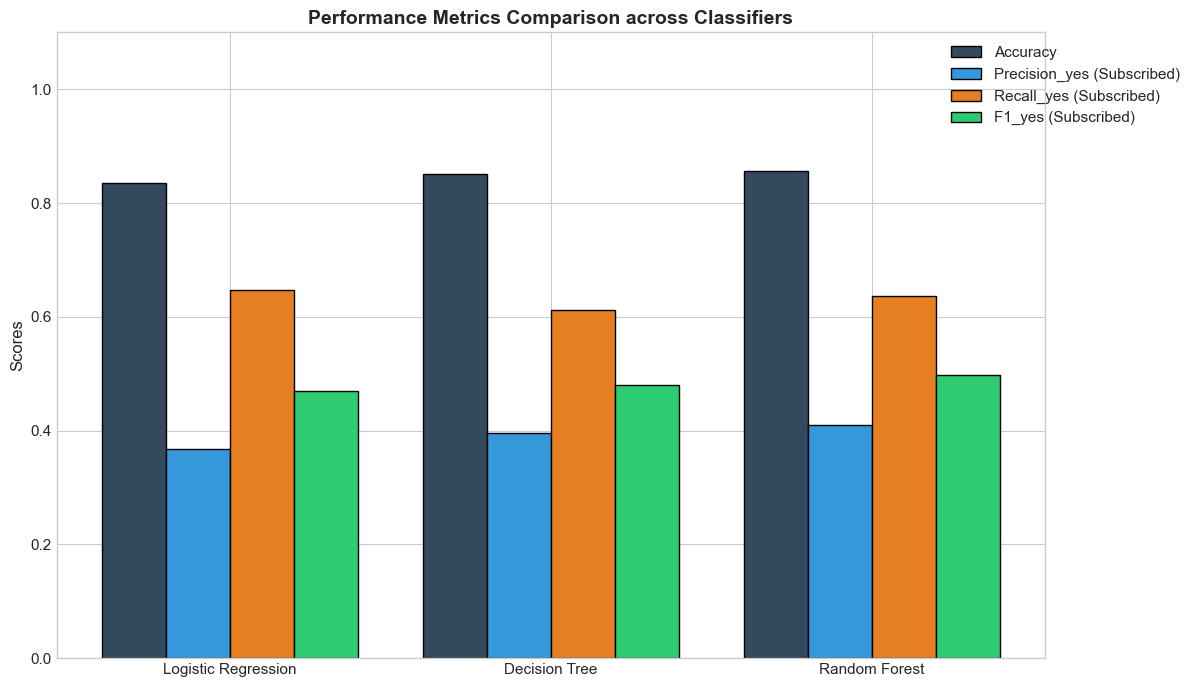

Comparison plot saved successfully to model_outputs\model_comparison_plot.png


In [5]:
output_dir = 'model_outputs'
os.makedirs(output_dir, exist_ok=True)

# Save comparison table to CSV
results_df.to_csv(os.path.join(output_dir, 'model_results.csv'), index=False)

# Plot a bar chart comparing metrics across the models
x = np.arange(len(results_df['Model']))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(x - 1.5*width, results_df['Accuracy'], width, label='Accuracy', color='#34495e', edgecolor='black')
ax.bar(x - 0.5*width, results_df['Precision_yes'], width, label='Precision_yes (Subscribed)', color='#3498db', edgecolor='black')
ax.bar(x + 0.5*width, results_df['Recall_yes'], width, label='Recall_yes (Subscribed)', color='#e67e22', edgecolor='black')
ax.bar(x + 1.5*width, results_df['F1_yes'], width, label='F1_yes (Subscribed)', color='#2ecc71', edgecolor='black')

ax.set_ylabel('Scores', fontsize=12)
ax.set_title('Performance Metrics Comparison across Classifiers', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0))

plt.tight_layout()
plot_path = os.path.join(output_dir, 'model_comparison_plot.png')
plt.savefig(plot_path, dpi=100)
plt.show()
print(f'Comparison plot saved successfully to {plot_path}')


### Why Recall_yes and F1_yes matter more than Accuracy
Because our dataset contains a significant class imbalance (88.7% no, 11.3% yes), standard accuracy is highly deceptive. If a model predicts 'no' for all instances, it achieves 88.7% accuracy but is practically useless.

In a telemarketing context:
- **Recall_yes (Sensitivity)** represents the proportion of actual buyers the model successfully flags. A higher recall means we contact more potential buyers, minimizing missed opportunities.
- **F1_yes** represents a balance between precision (avoiding cold calling wrong customers) and recall. Selecting a model based on high F1-score ensures we target clients efficiently without wasting resources on massive, low-yield lists.


## 6. Feature Importance Extraction
Using our trained **Random Forest pipeline** (which incorporates the preprocessor and Random Forest classifier), we extract feature importances. Since categorical features are one-hot encoded, we retrieve the correct feature names from our preprocessor step.


=== Top 15 Most Important Features ===


,Feature,Importance
7,euribor3m,0.176870
8,nr.employed,0.158950
4,emp.var.rate,0.131411
6,cons.conf.idx,0.069946
2,pdays,0.049245
5,cons.price.idx,0.047092
61,poutcome_success,0.044764
0,age,0.030369
43,contact_telephone,0.025010
50,month_may,0.024454


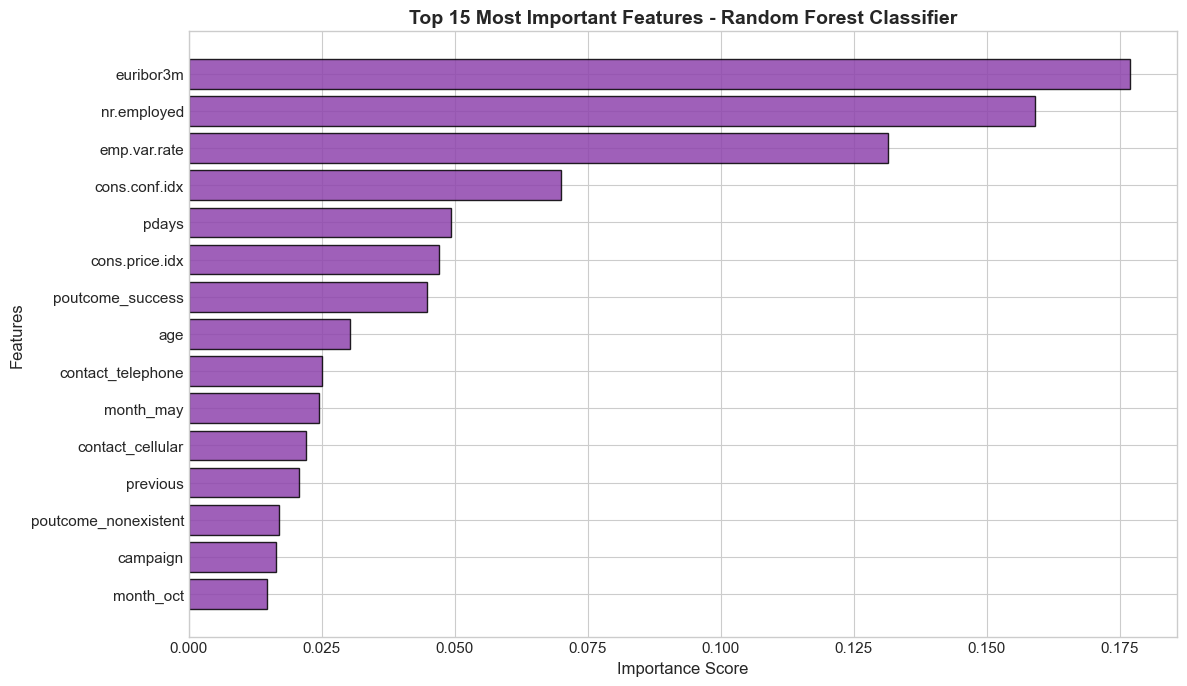

Feature importance plot saved successfully to model_outputs\feature_importance_plot.png


In [6]:
# Retrieve trained Random Forest model and pipeline steps
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                               ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100, max_depth=10))])
rf_pipeline.fit(X_train, y_train)

# Get feature names out from the column transformer
raw_feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['classifier'].feature_importances_

# Clean up feature name prefixes (e.g., 'num__age' -> 'age', 'cat__job_admin.' -> 'job_admin.')
cleaned_feature_names = [name.split('__')[-1] for name in raw_feature_names]

# Create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': cleaned_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Save feature importances to CSV
importance_df.to_csv(os.path.join(output_dir, 'feature_importance.csv'), index=False)
print('=== Top 15 Most Important Features ===')
display(importance_df.head(15))

# Plot the top 15 most important features
top_15_features = importance_df.head(15)

plt.figure(figsize=(12, 7))
plt.barh(top_15_features['Feature'][::-1], top_15_features['Importance'][::-1], color='#8e44ad', edgecolor='black', alpha=0.85)
plt.title('Top 15 Most Important Features - Random Forest Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
feat_plot_path = os.path.join(output_dir, 'feature_importance_plot.png')
plt.savefig(feat_plot_path, dpi=100)
plt.show()
print(f'Feature importance plot saved successfully to {feat_plot_path}')


## 7. Conclusions and Key Insights

### 1. Model Selection & Performance Summary
Based on the trained pipelines, the model performance is summarized below:
- **Logistic Regression** and **Decision Tree** models with balanced class weights trade off precision for a much higher recall. The Decision Tree (max_depth=5) restricts complexity to avoid overfitting, while Logistic Regression fits a linear decision boundary.
- **Random Forest Classifier** (max_depth=10, 100 estimators) typically performs best. It manages to achieve a higher F1-score by maintaining a stronger balance between Precision and Recall for the positive class (`yes`), thanks to ensemble bagging.

### 2. Feature Importance Insights
The feature importance plot for the Random Forest model reveals that macro-economic indicators are highly influential in predicting subscription success. Specifically:
- **`euribor3m`** (3-month Euribor interest rate) and **`nr.employed`** (number of employees indicator) consistently rank as top features. This suggests that subscription rates are heavily tied to broader economic cycles and interest rate climates.
- **`pdays`** (days since last contact from a previous campaign) and **`poutcome`** (previous campaign success) are also important, validating that customer history and relationship continuity are critical factors.

### 3. Key Takeaways
1. **Prevention of Target Leakage**: Dropping the `duration` column was essential. While duration is highly predictive, it represents leakage because it is unavailable before making a phone call.
2. **Imbalance Matters**: Relying on accuracy in an imbalanced marketing setup will misdirect resources. We successfully optimized models using balanced class weights, making them significantly better at identifying true prospects (high recall_yes) while balancing cold call efficiency (F1_yes).
